2025-06-08 08:44:35.025927: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749372275.244680      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749372275.304418      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Epoch 1/3 - Train Acc: 0.8304, Val Acc: 0.8498


Epoch 2/3: 100%|██████████| 2319/2319 [1:03:33<00:00,  1.64s/it, loss=0.324]


Epoch 2/3 - Train Acc: 0.8803, Val Acc: 0.8570


Epoch 3/3: 100%|██████████| 2319/2319 [1:03:33<00:00,  1.64s/it, loss=0.305]


Epoch 3/3 - Train Acc: 0.9204, Val Acc: 0.8541
Best Validation Accuracy: 0.8570


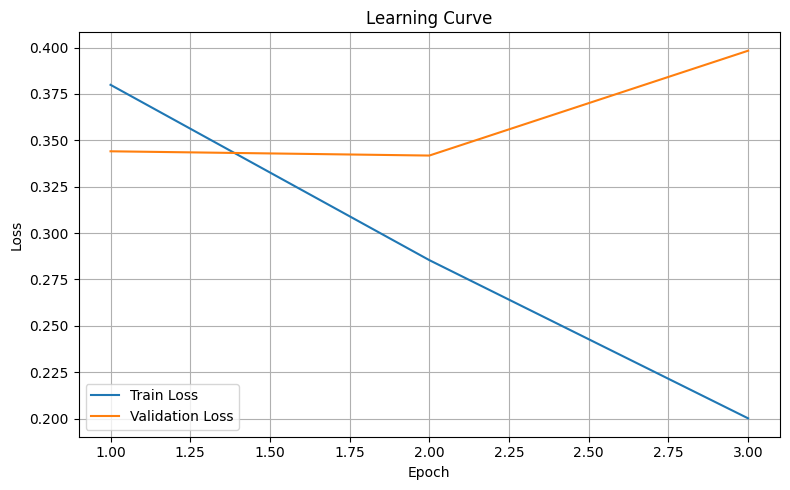

/tmp/ipykernel_19/4131397982.py:181: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_bert_model.pt"))


Validation Accuracy: 0.8569676385
Precision: 0.8630018708
Recall: 0.8486721072
F1 Score: 0.8557770061


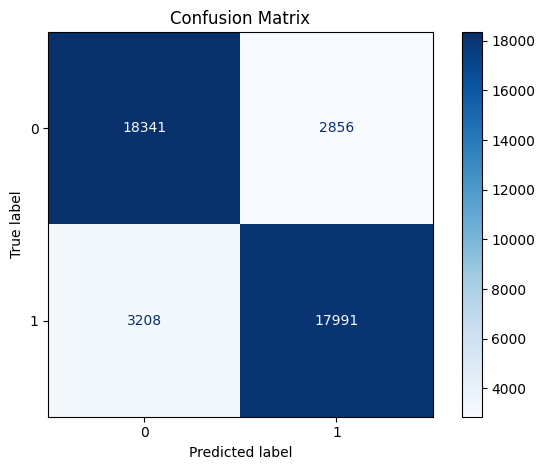

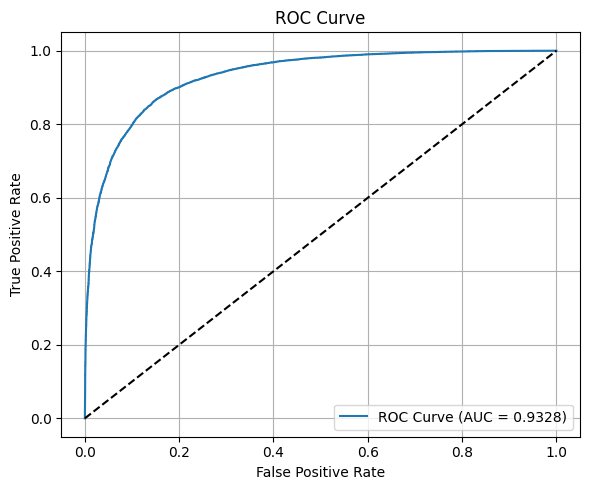

Test predictions saved!


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_cosine_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import random


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


train_path = "/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/train_dataset.csv"
val_path = "/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/val_dataset.csv"
test_path = "/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/test_dataset.csv"

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)


tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")


class BERTDataset(Dataset):
    def __init__(self, texts, labels=None, max_len=256):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        item = {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
        }
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


g = torch.Generator()
g.manual_seed(42)

train_dataset = BERTDataset(train_df["Text"].tolist(), train_df["Label"].tolist())
val_dataset = BERTDataset(valid_df["Text"].tolist(), valid_df["Label"].tolist())
test_dataset = BERTDataset(test_df["Text"].tolist(), None)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)


class BERTClassifier(nn.Module):
    def __init__(self, dropout=0.3):
        super(BERTClassifier, self).__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, 2)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        x = self.dropout(pooled_output)
        return self.classifier(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BERTClassifier()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-6)
total_steps = len(train_loader) * 4
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=3):
    best_acc = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss, total_correct = 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for batch in loop:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            _, preds = torch.max(outputs, dim=1)
            total_loss += loss.item()
            total_correct += torch.sum(preds == labels)

            loop.set_postfix(loss=loss.item())

        epoch_loss = total_loss / len(train_loader)
        train_losses.append(epoch_loss)
        train_acc = total_correct.double() / len(train_loader.dataset)

        val_loss = 0
        val_preds, val_labels = [], []
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        val_acc = accuracy_score(val_labels, val_preds)

        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_bert_model.pt")

    print(f"Best Validation Accuracy: {best_acc:.4f}")

    # Learning Curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, epochs + 1), train_losses, label="Train Loss")
    plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=3)


model.load_state_dict(torch.load("best_bert_model.pt"))
model.eval()


val_preds = []
val_probs = []
val_true = valid_df["Label"].tolist()

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, dim=1)

        val_preds.extend(preds.cpu().numpy())
        val_probs.extend(probs[:, 1].cpu().numpy())

accuracy = accuracy_score(val_true, val_preds)
precision = precision_score(val_true, val_preds)
recall = recall_score(val_true, val_preds)
f1 = f1_score(val_true, val_preds)

print(f"Validation Accuracy: {accuracy:.10f}")
print(f"Precision: {precision:.10f}")
print(f"Recall: {recall:.10f}")
print(f"F1 Score: {f1:.10f}")

cm = confusion_matrix(val_true, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(val_true, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


test_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())

test_df["Label"] = test_preds
test_df[["ID", "Label"]].to_csv("submission.csv", index=False)
print("Test predictions saved!")

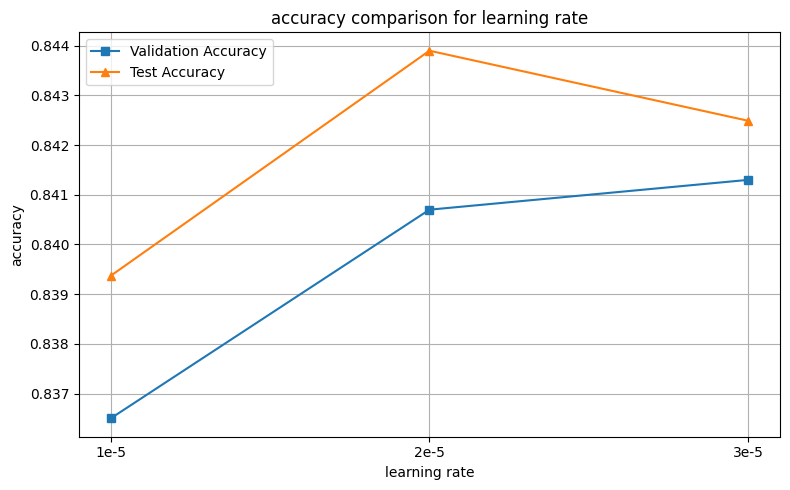

In [2]:
import matplotlib.pyplot as plt

# Data
learning_rates = ["1e-5", "2e-5", "3e-5"]
val_accuracy = [0.8365, 0.8407, 0.8413]
test_accuracy = [0.83937, 0.84390, 0.84249]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, val_accuracy, marker='s', label='Validation Accuracy')
plt.plot(learning_rates, test_accuracy, marker='^', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for learning rate')
plt.xlabel('learning rate')
plt.ylabel('accuracy')
plt.xticks(learning_rates)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

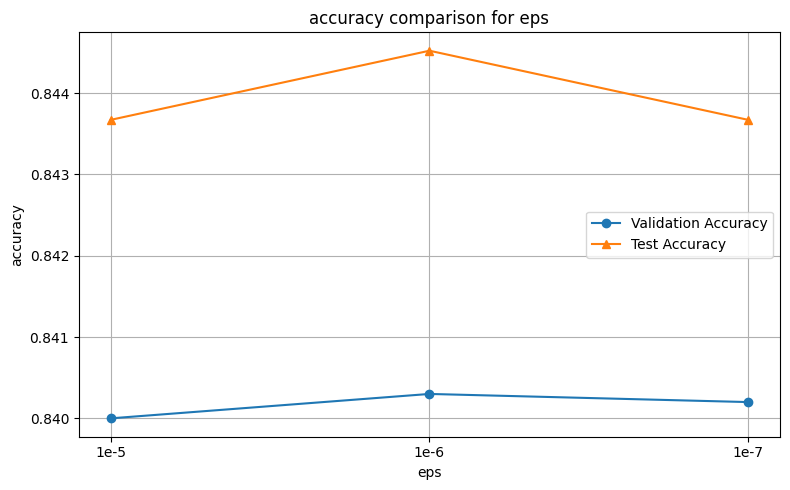

In [3]:
import matplotlib.pyplot as plt

# Data
epss = ["1e-5", "1e-6", "1e-7"]
val_accuracy = [0.84, 0.8403, 0.8402]
test_accuracy = [0.84367, 0.84452, 0.84367]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epss, val_accuracy, marker='o', label='Validation Accuracy')
plt.plot(epss, test_accuracy, marker='^', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for eps')
plt.xlabel('eps')
plt.ylabel('accuracy')
plt.xticks(epss)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

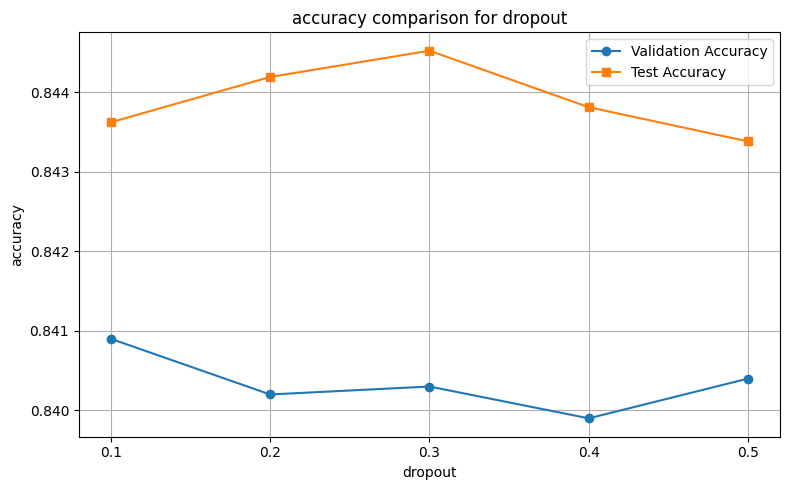

In [4]:
import matplotlib.pyplot as plt

# Data
dropouts = [0.1, 0.2, 0.3, 0.4, 0.5]
val_accuracy = [0.8409, 0.8402, 0.8403, 0.8399, 0.8404]
test_accuracy = [0.84362, 0.84419, 0.84452, 0.84381, 0.84338]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(dropouts, val_accuracy, marker='o', label='Validation Accuracy')
plt.plot(dropouts, test_accuracy, marker='s', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for dropout')
plt.xlabel('dropout')
plt.ylabel('accuracy')
plt.xticks(dropouts)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

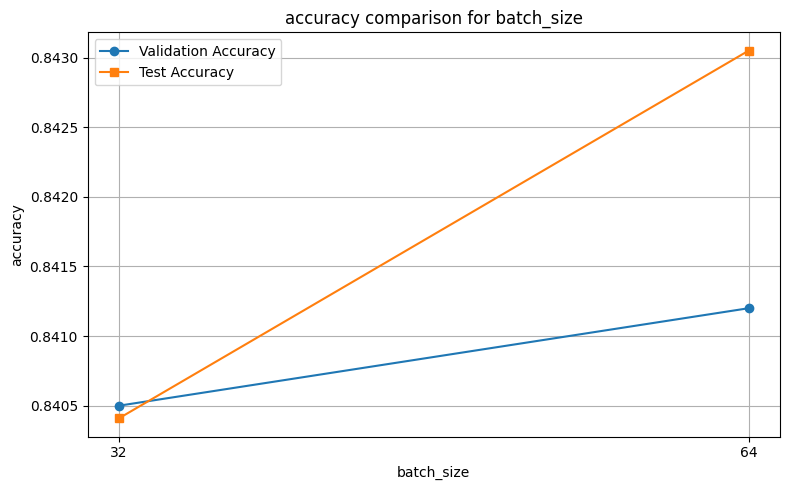

In [5]:
import matplotlib.pyplot as plt

# Data
batches = [32, 64]
val_accuracy = [0.8405, 0.8412]
test_accuracy = [0.84041, 0.84305]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(batches, val_accuracy, marker='o', label='Validation Accuracy')
plt.plot(batches, test_accuracy, marker='s', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for batch_size')
plt.xlabel('batch_size')
plt.ylabel('accuracy')
plt.xticks(batches)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

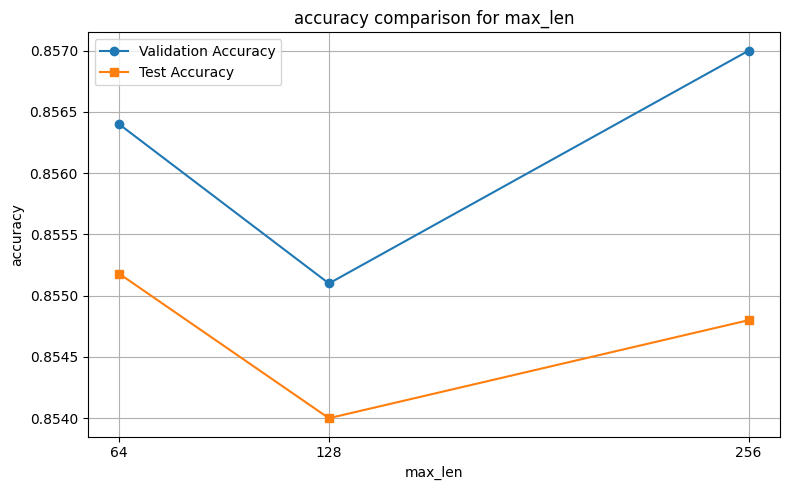

In [6]:
import matplotlib.pyplot as plt

# Data
lengths = [64, 128, 256]
val_accuracy = [0.8564, 0.8551, 0.8570]
test_accuracy = [0.85518, 0.85400, 0.85480]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lengths, val_accuracy, marker='o', label='Validation Accuracy')
plt.plot(lengths, test_accuracy, marker='s', label='Test Accuracy')

# Formatting
plt.title('accuracy comparison for max_len')
plt.xlabel('max_len')
plt.ylabel('accuracy')
plt.xticks(lengths)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()